
# 📊 EDA — Amazon Delivery Time Prediction

This notebook explores the dataset, engineers features used in the model (time & distance),
and visualizes relationships that affect **Delivery_Time**.


In [1]:

# ---- Configuration ----
DATA_PATH = "data/amazon_delivery.csv"  # change if your CSV is elsewhere
SAVE_ENGINEERED = True                   # set False to skip saving engineered CSV
ENGINEERED_OUT = "data/amazon_delivery_engineered.csv"


In [2]:

import pandas as pd
import numpy as np
from pathlib import Path
from math import radians, sin, cos, sqrt, atan2
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)


In [3]:

# ---- Load data ----
path = Path(DATA_PATH)
if not path.exists():
    raise FileNotFoundError(f"CSV not found: {path.resolve()}")

df = pd.read_csv(path)
print("Shape:", df.shape)
df.head()


Shape: (43739, 16)


,Order_ID,Agent_Age,Agent_Rating,Store_Latitude,Store_Longitude,Drop_Latitude,Drop_Longitude,Order_Date,Order_Time,Pickup_Time,Weather,Traffic,Vehicle,Area,Delivery_Time,Category
0,ialx566343618,37,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,11:30:00,11:45:00,Sunny,High,motorcycle,Urban,120,Clothing
1,akqg208421122,34,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,19:45:00,19:50:00,Stormy,Jam,scooter,Metropolitian,165,Electronics
2,njpu434582536,23,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,08:30:00,08:45:00,Sandstorms,Low,motorcycle,Urban,130,Sports
3,rjto796129700,38,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,18:00:00,18:10:00,Sunny,Medium,motorcycle,Metropolitian,105,Cosmetics
4,zguw716275638,32,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,13:30:00,13:45:00,Cloudy,High,scooter,Metropolitian,150,Toys


In [4]:

# ---- Overview ----
display(df.sample(min(5, len(df))))
print("\nInfo:")
print(df.info())
display(df.describe(include="all").T)


,Order_ID,Agent_Age,Agent_Rating,Store_Latitude,Store_Longitude,Drop_Latitude,Drop_Longitude,Order_Date,Order_Time,Pickup_Time,Weather,Traffic,Vehicle,Area,Delivery_Time,Category
36025,gpsi466706453,25,4.6,22.539129,88.365507,22.569129,88.395507,2022-02-17,19:00:00,19:15:00,Stormy,Medium,scooter,Metropolitian,28,Grocery
27803,mhwf297600449,35,4.9,17.438263,78.397865,17.468263,78.427865,2022-03-30,20:25:00,20:30:00,Fog,Jam,scooter,Metropolitian,180,Snacks
43451,ksgf137225654,34,4.6,19.181300,72.836191,19.271300,72.926191,2022-03-18,18:45:00,19:00:00,Stormy,Medium,motorcycle,Metropolitian,100,Apparel
29418,bbxw368663312,24,4.6,17.422819,78.449578,17.452819,78.479578,2022-03-15,17:50:00,18:05:00,Sandstorms,Medium,motorcycle,Metropolitian,125,Outdoors
38031,poxe594972410,32,4.7,12.323194,76.630583,12.363194,76.670583,2022-03-13,14:40:00,14:55:00,Stormy,High,motorcycle,Urban,140,Electronics



Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43739 entries, 0 to 43738
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order_ID         43739 non-null  object 
 1   Agent_Age        43739 non-null  int64  
 2   Agent_Rating     43685 non-null  float64
 3   Store_Latitude   43739 non-null  float64
 4   Store_Longitude  43739 non-null  float64
 5   Drop_Latitude    43739 non-null  float64
 6   Drop_Longitude   43739 non-null  float64
 7   Order_Date       43739 non-null  object 
 8   Order_Time       43739 non-null  object 
 9   Pickup_Time      43739 non-null  object 
 10  Weather          43648 non-null  object 
 11  Traffic          43739 non-null  object 
 12  Vehicle          43739 non-null  object 
 13  Area             43739 non-null  object 
 14  Delivery_Time    43739 non-null  int64  
 15  Category         43739 non-null  object 
dtypes: float64(5), int64(2), object(9)
memory usage: 5.

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Order_ID,43739,43739,ialx566343618,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Agent_Age,43739.0,NaN,NaN,NaN,29.567137,5.815155,15.0,25.0,30.0,35.0,50.0
Agent_Rating,43685.0,NaN,NaN,NaN,4.63378,0.334716,1.0,4.5,4.7,4.9,6.0
Store_Latitude,43739.0,NaN,NaN,NaN,17.21096,7.764225,-30.902872,12.933298,18.55144,22.732225,30.914057
Store_Longitude,43739.0,NaN,NaN,NaN,70.661177,21.475005,-88.366217,73.170283,75.898497,78.045359,88.433452
Drop_Latitude,43739.0,NaN,NaN,NaN,17.459031,7.34295,0.01,12.985996,18.633626,22.785049,31.054057
Drop_Longitude,43739.0,NaN,NaN,NaN,70.821842,21.153148,0.01,73.28,76.002574,78.104095,88.563452
Order_Date,43739,44,2022-03-15,1141,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Order_Time,43739,177,21:55:00,460,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Pickup_Time,43739,193,21:30:00,481,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:

# ---- Feature Engineering (matches training pipeline) ----

def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0
    dlat = radians(lat2 - lat1)
    dlon = radians(lon2 - lon1)
    a = sin(dlat/2)**2 + cos(radians(lat1)) * cos(radians(lat2)) * sin(dlon/2)**2
    return R * 2 * atan2(sqrt(a), sqrt(1 - a))

def engineer_features(df_in: pd.DataFrame) -> pd.DataFrame:
    out = df_in.copy()

    # Order timestamp
    if "Order_Date" in out.columns:
        out["Order_Date"] = pd.to_datetime(out["Order_Date"], errors="coerce")
        out["Order_Hour"] = out["Order_Date"].dt.hour
        out["Order_DayOfWeek"] = out["Order_Date"].dt.dayofweek

    # Pickup delay
    if "Pickup_Time" in out.columns and "Order_Date" in out.columns:
        out["Pickup_Time"] = pd.to_datetime(out["Pickup_Time"], errors="coerce")
        out["Pickup_Delay"] = ((out["Pickup_Time"] - out["Order_Date"]).dt.total_seconds() / 60).fillna(0)
    else:
        out["Pickup_Delay"] = np.nan

    # Distance (km)
    if {"Store_Lat", "Store_Long", "Drop_Lat", "Drop_Long"}.issubset(out.columns):
        out["distance_km"] = out.apply(
            lambda r: haversine(r["Store_Lat"], r["Store_Long"], r["Drop_Lat"], r["Drop_Long"]), axis=1
        )
    else:
        out["distance_km"] = np.nan

    # Drop raw datetime columns (model uses engineered numbers)
    for col in ["Order_Date", "Pickup_Time"]:
        if col in out.columns:
            out = out.drop(columns=[col])

    return out

df_eng = engineer_features(df)
print("Engineered shape:", df_eng.shape)
df_eng.head()


Engineered shape: (43739, 18)


C:\Users\user\AppData\Local\Temp\ipykernel_7120\1830721215.py:21: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  out["Pickup_Time"] = pd.to_datetime(out["Pickup_Time"], errors="coerce")


,Order_ID,Agent_Age,Agent_Rating,Store_Latitude,Store_Longitude,Drop_Latitude,Drop_Longitude,Order_Time,Weather,Traffic,Vehicle,Area,Delivery_Time,Category,Order_Hour,Order_DayOfWeek,Pickup_Delay,distance_km
0,ialx566343618,37,4.9,22.745049,75.892471,22.765049,75.912471,11:30:00,Sunny,High,motorcycle,Urban,120,Clothing,0,5,1855425.0,NaN
1,akqg208421122,34,4.5,12.913041,77.683237,13.043041,77.813237,19:45:00,Stormy,Jam,scooter,Metropolitian,165,Electronics,0,4,1847270.0,NaN
2,njpu434582536,23,4.4,12.914264,77.678400,12.924264,77.688400,08:30:00,Sandstorms,Low,motorcycle,Urban,130,Sports,0,5,1855245.0,NaN
3,rjto796129700,38,4.7,11.003669,76.976494,11.053669,77.026494,18:00:00,Sunny,Medium,motorcycle,Metropolitian,105,Cosmetics,0,1,1831330.0,NaN
4,zguw716275638,32,4.6,12.972793,80.249982,13.012793,80.289982,13:30:00,Cloudy,High,scooter,Metropolitian,150,Toys,0,5,1845465.0,NaN


In [6]:

if SAVE_ENGINEERED:
    Path(ENGINEERED_OUT).parent.mkdir(parents=True, exist_ok=True)
    df_eng.to_csv(ENGINEERED_OUT, index=False)
    print(f"Saved engineered dataset to {ENGINEERED_OUT}")


Saved engineered dataset to data/amazon_delivery_engineered.csv


In [7]:

# ---- Target checks ----
TARGET = None
for c in ["Delivery_Time", "delivery_time", "target", "DeliveryTime", "y"]:
    if c in df.columns:
        TARGET = c
        break

if TARGET is None:
    raise ValueError("Target column not found. Expected one of Delivery_Time / delivery_time / target")

y = df[TARGET].values
print("Target column:", TARGET, "| min/max/mean:", np.min(y), np.max(y), np.mean(y))


Target column: Delivery_Time | min/max/mean: 10 270 124.90564484784746


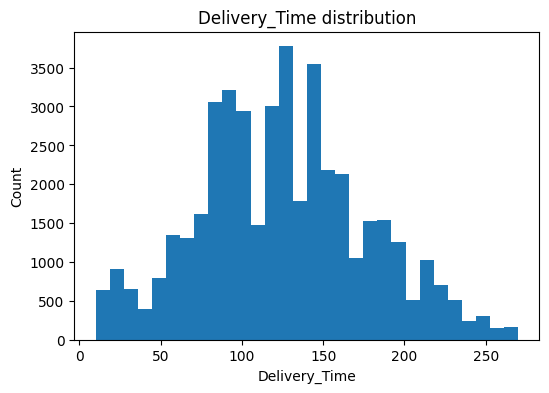

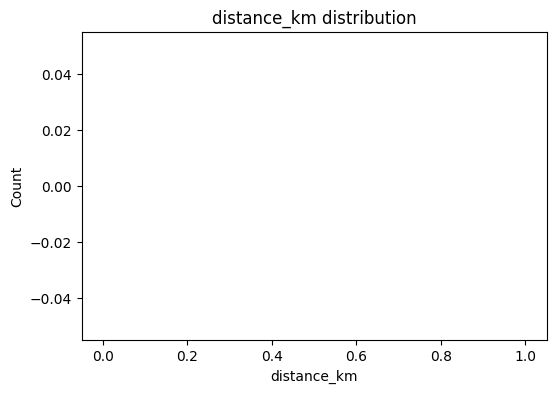

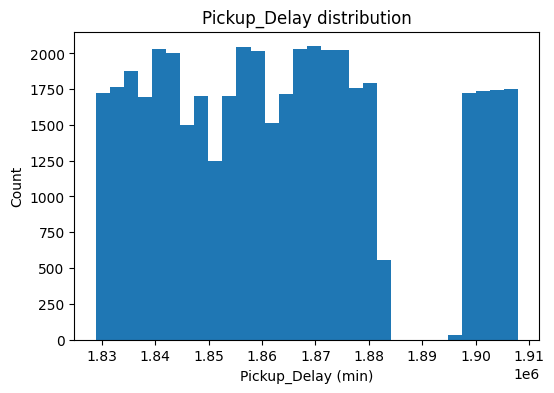

In [8]:

# ---- Histograms ----
plt.figure(figsize=(6,4))
plt.hist(y, bins=30)
plt.title("Delivery_Time distribution")
plt.xlabel("Delivery_Time")
plt.ylabel("Count")
plt.show()

if "distance_km" in df_eng.columns:
    plt.figure(figsize=(6,4))
    plt.hist(df_eng["distance_km"].dropna(), bins=30)
    plt.title("distance_km distribution")
    plt.xlabel("distance_km")
    plt.ylabel("Count")
    plt.show()

if "Pickup_Delay" in df_eng.columns:
    plt.figure(figsize=(6,4))
    plt.hist(df_eng["Pickup_Delay"].dropna(), bins=30)
    plt.title("Pickup_Delay distribution")
    plt.xlabel("Pickup_Delay (min)")
    plt.ylabel("Count")
    plt.show()


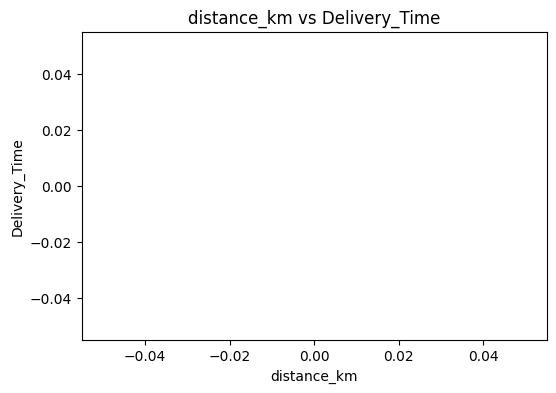

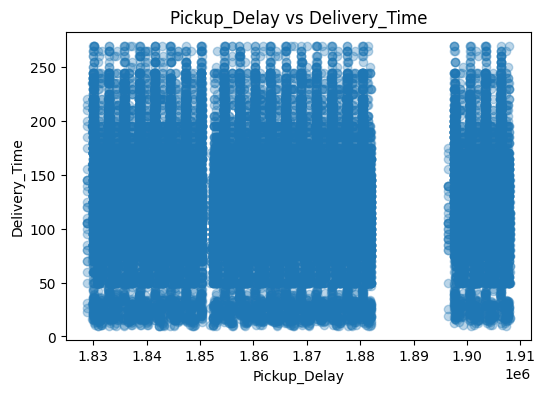

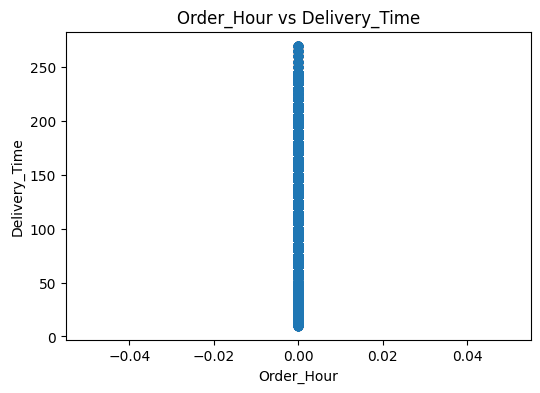

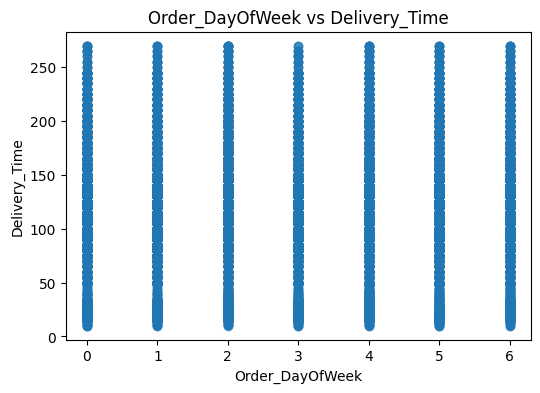

In [9]:

# ---- Relationships with target ----
import numpy as np

def safe_scatter(x, x_label):
    mask = ~pd.isna(x) & ~pd.isna(y)
    plt.figure(figsize=(6,4))
    plt.scatter(x[mask], y[mask], alpha=0.3)
    plt.xlabel(x_label); plt.ylabel(TARGET)
    plt.title(f"{x_label} vs {TARGET}")
    plt.show()

for col in ["distance_km", "Pickup_Delay", "Order_Hour", "Order_DayOfWeek"]:
    if col in df_eng.columns:
        safe_scatter(df_eng[col].values, col)


C:\Users\user\AppData\Local\Temp\ipykernel_7120\2676619625.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(vals, labels=labels, showfliers=False)


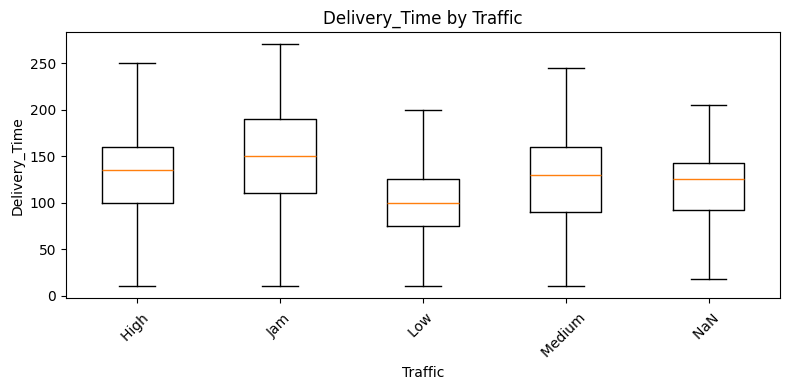

C:\Users\user\AppData\Local\Temp\ipykernel_7120\2676619625.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(vals, labels=labels, showfliers=False)


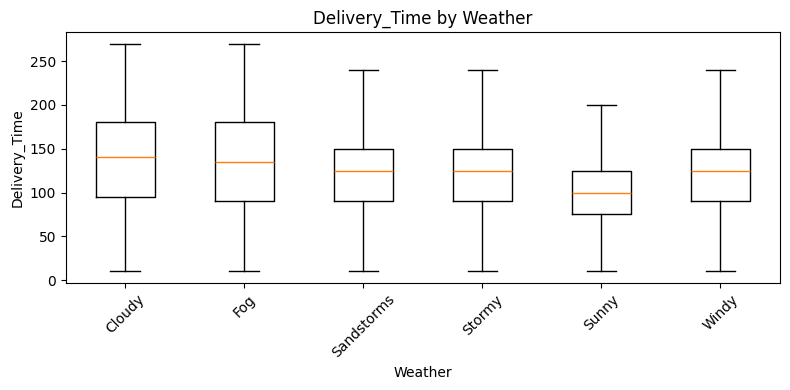

C:\Users\user\AppData\Local\Temp\ipykernel_7120\2676619625.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(vals, labels=labels, showfliers=False)


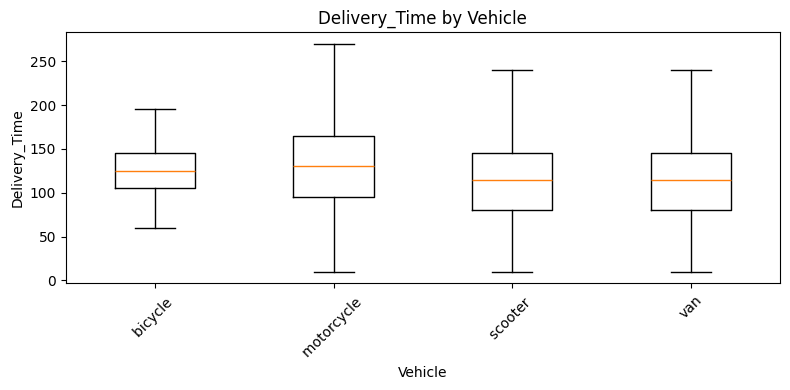

C:\Users\user\AppData\Local\Temp\ipykernel_7120\2676619625.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(vals, labels=labels, showfliers=False)


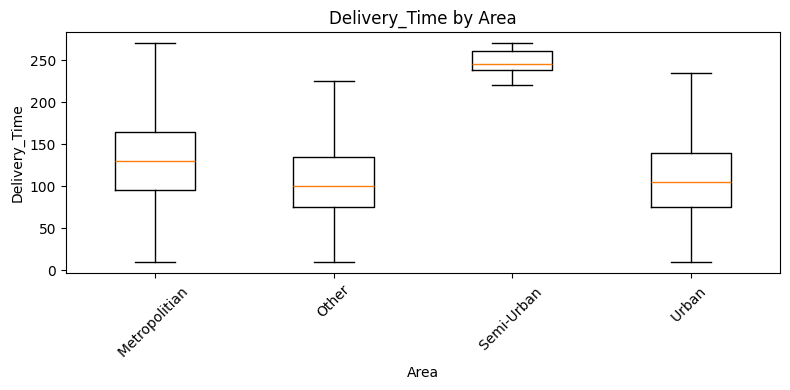

C:\Users\user\AppData\Local\Temp\ipykernel_7120\2676619625.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(vals, labels=labels, showfliers=False)


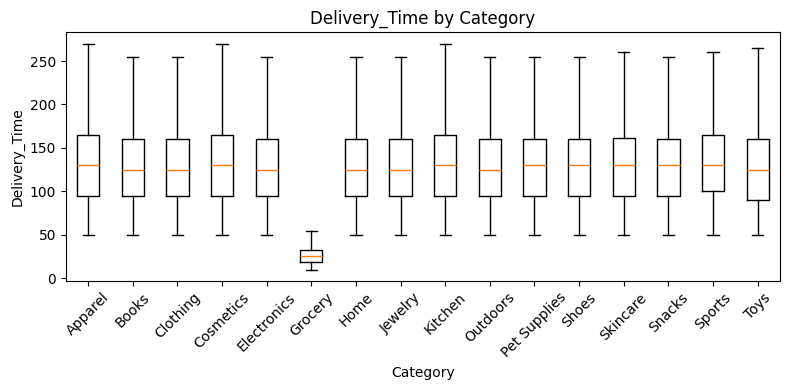

In [10]:

# ---- Boxplots by categorical features ----
def box_by_cat(cat_col):
    if cat_col in df.columns:
        vals = []
        labels = []
        for k, g in df.groupby(cat_col):
            labels.append(str(k))
            vals.append(g[TARGET].values)
        if len(vals) > 1:
            plt.figure(figsize=(8,4))
            plt.boxplot(vals, labels=labels, showfliers=False)
            plt.title(f"{TARGET} by {cat_col}")
            plt.xlabel(cat_col); plt.ylabel(TARGET)
            plt.xticks(rotation=45)
            plt.tight_layout()
            plt.show()

for cat in ["Traffic", "Weather", "Vehicle", "Area", "Category"]:
    box_by_cat(cat)


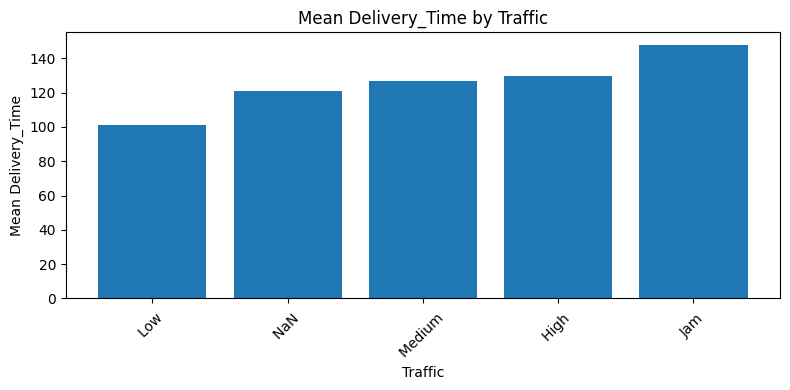

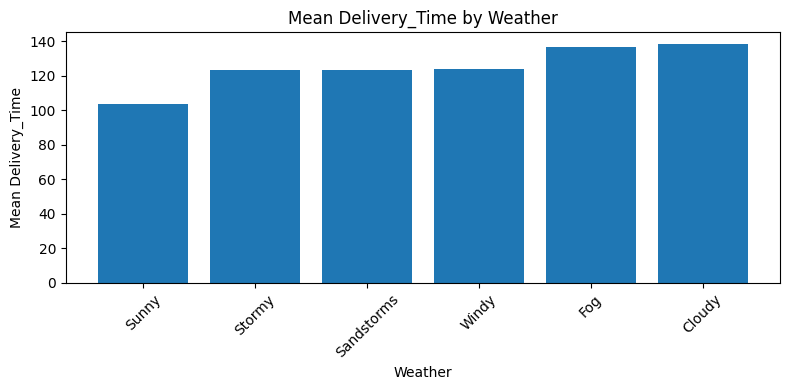

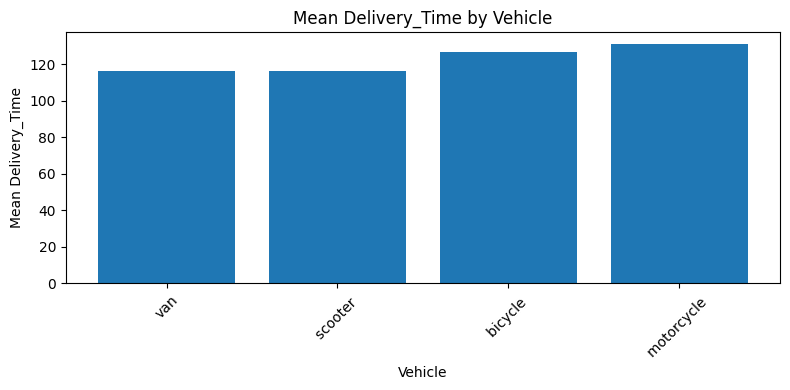

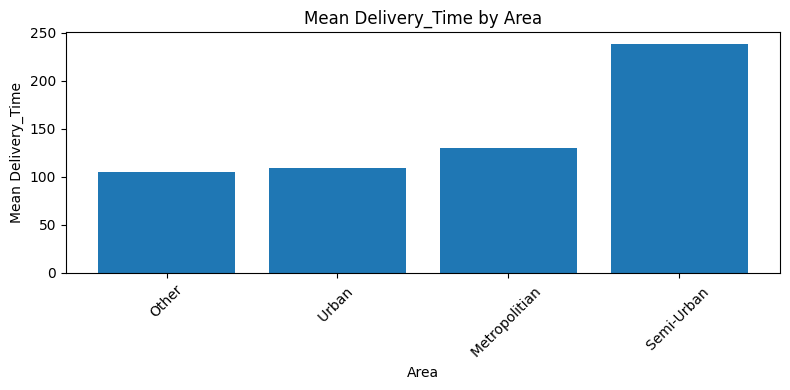

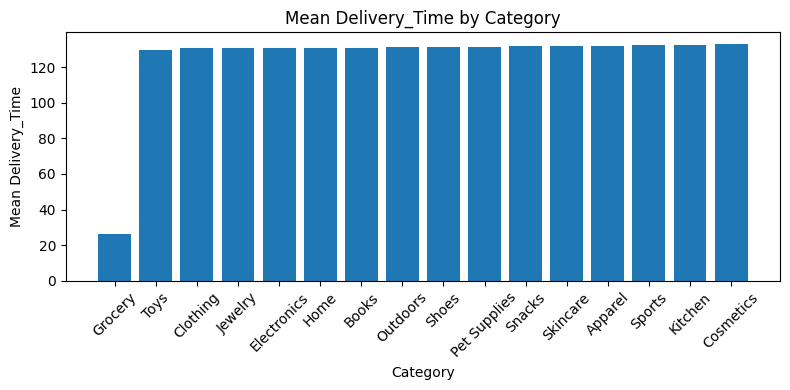

In [11]:

# ---- Mean delivery time by category ----
def bar_means(cat_col):
    if cat_col in df.columns:
        order = df.groupby(cat_col)[TARGET].mean().sort_values()
        plt.figure(figsize=(8,4))
        plt.bar(order.index.astype(str), order.values)
        plt.title(f"Mean {TARGET} by {cat_col}")
        plt.xlabel(cat_col); plt.ylabel(f"Mean {TARGET}")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

for cat in ["Traffic", "Weather", "Vehicle", "Area", "Category"]:
    bar_means(cat)


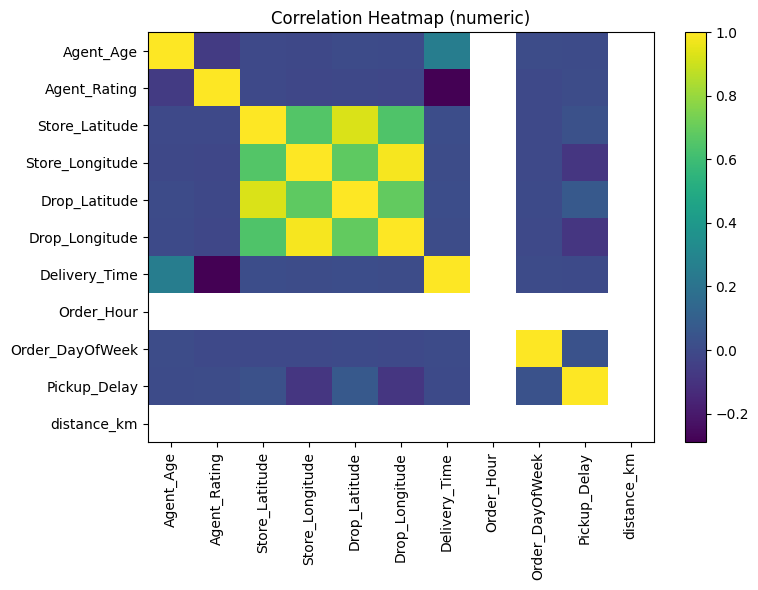

Top correlations with target:


Delivery_Time      1.000000
Agent_Age          0.254618
Store_Latitude     0.017009
Drop_Latitude      0.016928
Drop_Longitude     0.011523
Store_Longitude    0.011173
Order_DayOfWeek    0.006360
Pickup_Delay       0.000640
Agent_Rating      -0.289984
Order_Hour              NaN
Name: Delivery_Time, dtype: float64

In [12]:

# ---- Correlation heatmap (numeric features only) ----
num_df = df_eng.select_dtypes(include=[np.number]).copy()
if TARGET in df.columns and TARGET not in num_df.columns:
    num_df[TARGET] = pd.to_numeric(df[TARGET], errors="coerce")

corr = num_df.corr(numeric_only=True)
plt.figure(figsize=(8,6))
plt.imshow(corr.values, aspect="auto")
plt.xticks(ticks=range(len(corr.columns)), labels=corr.columns, rotation=90)
plt.yticks(ticks=range(len(corr.index)), labels=corr.index)
plt.title("Correlation Heatmap (numeric)")
plt.colorbar()
plt.tight_layout()
plt.show()

# Show top correlations with target
if TARGET in corr.columns:
    print("Top correlations with target:")
    display(corr[TARGET].sort_values(ascending=False).head(10))
